In [6]:
from IPython.display import HTML, SVG, display
from pathlib import Path

example_data_dir = Path("./example_data/")

# Visualise a BGC and subcluster

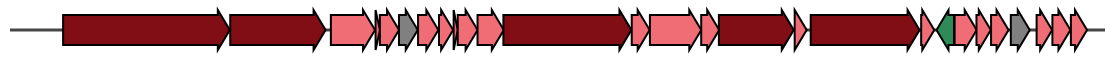

In [7]:
from subsketch.draw.bgc import draw_bgc
from subsketch.loaders import load_bgc

bgc_id = "BGC0001059"
bgc_data = load_bgc(example_data_dir / "mibig_4.0_gbks" / f"{bgc_id}.gbk")

# antismash gene colors
bgc_svgstr = draw_bgc(
    bgc_data,
    scaling=60,
)
display(SVG(bgc_svgstr))

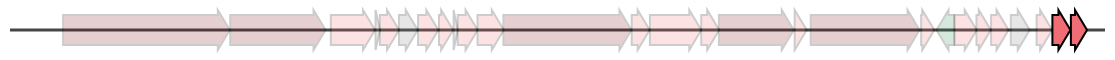

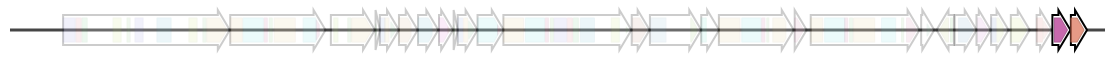

In [8]:
from subsketch.draw.bgc import draw_subcluster_hit
from subsketch.io import read_domain_hits, read_detected_motifs, read_color_domains_file

domains = read_domain_hits(example_data_dir / "mibig_4.0_domain_hits.txt")
bgc2hits, motif2hits = read_detected_motifs(example_data_dir / "mibig_4.0_detected_motifs.tsv")
motif_hit = bgc2hits[bgc_id][0] # take the first hit for this BGC

domain_colors = read_color_domains_file()

# antismash gene colors
subcluster_svg = draw_subcluster_hit(
    bgc_data=bgc_data,
    motif_hit=motif_hit,
    bgc_domain_hits=domains.get(bgc_id, {}),
    domain_colors=domain_colors,
    color_genes=True,
    scaling=60,
)
display(SVG(subcluster_svg))

# domains
subcluster_svg = draw_subcluster_hit(
    bgc_data=bgc_data,
    motif_hit=motif_hit,
    bgc_domain_hits=domains.get(bgc_id, {}),
    domain_colors=domain_colors,
    scaling=60,
)
display(SVG(subcluster_svg))

# Visualize a compound

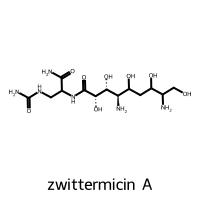

In [9]:
from subsketch.io import read_compounds
from subsketch.draw.molecule import draw_compounds

mibig_compounds = read_compounds(example_data_dir / "mibig_4.0_compounds.tsv")
compounds = mibig_compounds.get("BGC0001059", [])

# Draw the compounds associated with the BGC
compounds_svgstr = draw_compounds(
    compounds=compounds,
    show_names=True,
    scaling=1.0)

display(SVG(compounds_svgstr))

# Visualise a subcluster motif

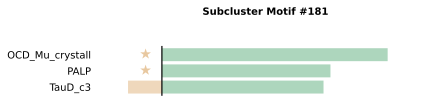

In [10]:
from subsketch.io import read_motifs
from subsketch.draw.motif import plot_subcluster_motif

motifs = read_motifs(example_data_dir / "clusterclue_motifs.txt")
motif = motifs["181"]

motif_svg = plot_subcluster_motif(
    motif,
    add_title=True,
)
display(SVG(motif_svg))

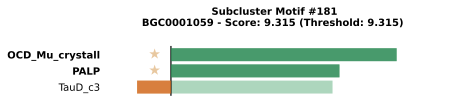

In [ ]:
# highlight the genes present in the motif hit

bgc2hits, motif2hits = read_detected_motifs(example_data_dir / "mibig_4.0_detected_motifs.tsv")
hit = bgc2hits[bgc_id][0] # take the first hit for this BGC

motif_svg = plot_subcluster_motif(
    motif,
    hit,
    add_title=True,
)
display(SVG(motif_svg))